Medias empiricas de nu:
  E[nu_1]    = 0.4999
  E[nu_rand] = 0.5005
  E[nu_min]  = 0.0375


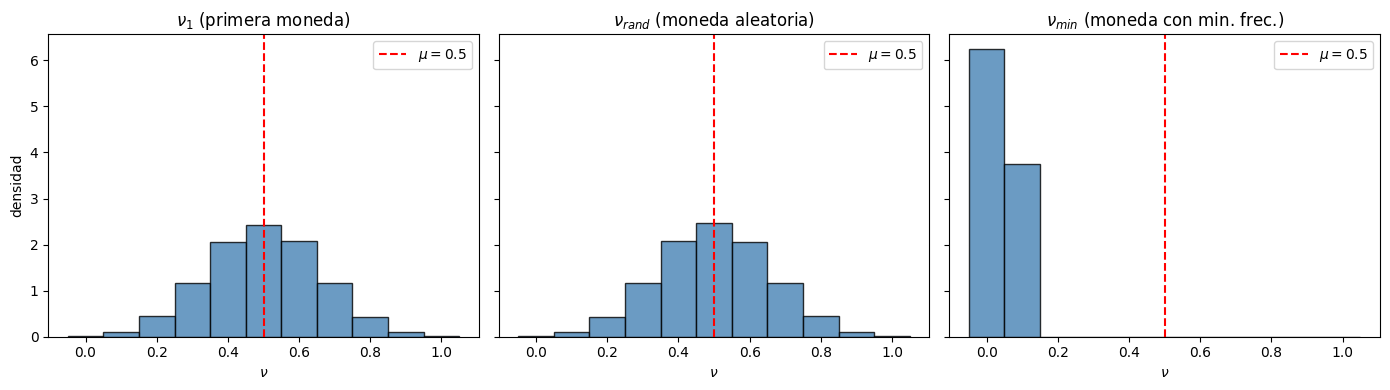


Ejemplo de violacion en epsilon=0.4:
  eps=0.40  Hoeffding bound=0.08422
  P[|nu_1-mu|>eps]    = 0.02167  (obedece: True)
  P[|nu_rand-mu|>eps] = 0.02085  (obedece: True)
  P[|nu_min-mu|>eps]  = 0.99997  (obedece: False)


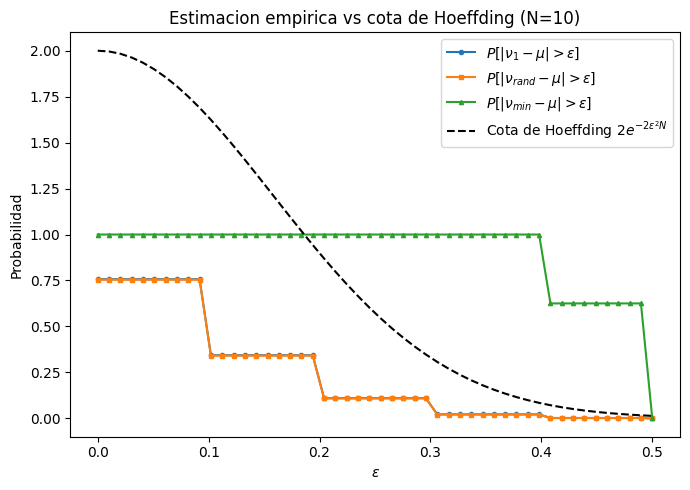

In [ ]:
#El siguiente código se implementó con el apoyo de la IA Claude Sonet 5 con esfuerzo medio

#Se hace uso de una muestra aleatoria para las 1000 monedas que se distribuyen respecto a una Bernoulli(0.5)
#Por eficiencia computacional se usa la distribución Binomail(10, 0.5) con el fin de realizar los 10 conteos independientes de una sola vez

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

N_COINS = 1000
N_FLIPS = 10
N_RUNS  = 100_000
MU = 0.5

nu1_all   = np.empty(N_RUNS)
nurand_all = np.empty(N_RUNS)
numin_all  = np.empty(N_RUNS)

BATCH = 5000  # procesar por lotes para no agotar memoria
for start in range(0, N_RUNS, BATCH):
    end = min(start + BATCH, N_RUNS)
    b = end - start

    # conteo de caras en 10 lanzamientos, para las 1000 monedas, en b corridas
    counts = rng.binomial(N_FLIPS, MU, size=(b, N_COINS))  # shape (b, 1000)

    # c_1: primera moneda (columna 0)
    nu1_all[start:end] = counts[:, 0] / N_FLIPS

    # c_rand: una moneda aleatoria por corrida
    rand_idx = rng.integers(0, N_COINS, size=b)
    nurand_all[start:end] = counts[np.arange(b), rand_idx] / N_FLIPS

    # c_min: moneda con frecuencia minima de caras (empate -> primera en aparecer, argmin ya hace eso)
    min_idx = np.argmin(counts, axis=1)
    numin_all[start:end] = counts[np.arange(b), min_idx] / N_FLIPS

# ---------- (b) Histogramas ----------
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
titles = [r'$\nu_1$ (primera moneda)', r'$\nu_{rand}$ (moneda aleatoria)', r'$\nu_{min}$ (moneda con min. frec.)']
data_sets = [nu1_all, nurand_all, numin_all]
bins = np.arange(-0.05, 1.1, 0.1)


print(f"Medias empiricas de nu:")
print(f"  E[nu_1]    = {nu1_all.mean():.4f}")
print(f"  E[nu_rand] = {nurand_all.mean():.4f}")
print(f"  E[nu_min]  = {numin_all.mean():.4f}")

for ax, data, title in zip(axes, data_sets, titles):
    ax.hist(data, bins=bins, density=True, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(r'$\nu$')
    ax.axvline(MU, color='red', linestyle='--', label=r'$\mu=0.5$')
    ax.legend()
axes[0].set_ylabel('densidad')
plt.tight_layout()
plt.savefig('histograms.png', dpi=140)
plt.show()
plt.close()


# ---------- (c) P[|nu - mu| > epsilon] vs cota de Hoeffding ----------
epsilons = np.linspace(0, 0.5, 50)

def empirical_tail(data, eps_array):
    return np.array([(np.abs(data - MU) > eps).mean() for eps in eps_array])

p1    = empirical_tail(nu1_all, epsilons)
prand = empirical_tail(nurand_all, epsilons)
pmin  = empirical_tail(numin_all, epsilons)

hoeffding = 2 * np.exp(-2 * (epsilons**2) * N_FLIPS)

print()
print("Ejemplo de violacion en epsilon=0.4:")
idx = np.argmin(np.abs(epsilons-0.4))
print(f"  eps={epsilons[idx]:.2f}  Hoeffding bound={hoeffding[idx]:.5f}")
print(f"  P[|nu_1-mu|>eps]    = {p1[idx]:.5f}  (obedece: {p1[idx]<=hoeffding[idx]})")
print(f"  P[|nu_rand-mu|>eps] = {prand[idx]:.5f}  (obedece: {prand[idx]<=hoeffding[idx]})")
print(f"  P[|nu_min-mu|>eps]  = {pmin[idx]:.5f}  (obedece: {pmin[idx]<=hoeffding[idx]})")

plt.figure(figsize=(7,5))
plt.plot(epsilons, p1,    label=r'$P[|\nu_1-\mu|>\epsilon]$', marker='o', ms=3)
plt.plot(epsilons, prand, label=r'$P[|\nu_{rand}-\mu|>\epsilon]$', marker='s', ms=3)
plt.plot(epsilons, pmin,  label=r'$P[|\nu_{min}-\mu|>\epsilon]$', marker='^', ms=3)
plt.plot(epsilons, hoeffding, 'k--', label=r'Cota de Hoeffding $2e^{-2\epsilon^2 N}$')
plt.xlabel(r'$\epsilon$')
plt.ylabel('Probabilidad')
plt.title('Estimacion empirica vs cota de Hoeffding (N=10)')
plt.legend()
plt.tight_layout()
plt.savefig('hoeffding_bound.png', dpi=140)
plt.show()
plt.close()


In [1]:
"""Implementación Perceptrón"""

import numpy as np

def generate_linearly_separable_data(N, seed=0):
    """Genera N puntos en [-1,1]^2 y una recta objetivo aleatoria f."""
    rng = np.random.default_rng(seed)
    # recta objetivo definida por 2 puntos aleatorios
    p1, p2 = rng.uniform(-1, 1, 2), rng.uniform(-1, 1, 2)
    # vector normal a la recta que pasa por p1,p2
    w_f = np.array([p2[1]-p1[1], -(p2[0]-p1[0])])
    b_f = -w_f @ p1

    X = rng.uniform(-1, 1, size=(N, 2))
    y = np.sign(X @ w_f + b_f)
    y[y == 0] = 1
    return X, y, (w_f, b_f)

def pla(X, y, max_iters=10000):
    """Perceptron Learning Algorithm: devuelve w (incluye bias), num_iters."""
    N, d = X.shape
    Xb = np.hstack([np.ones((N, 1)), X])   # agrega columna de 1's para el bias
    w = np.zeros(d + 1)

    for t in range(max_iters):
        preds = np.sign(Xb @ w)
        preds[preds == 0] = 1
        misclassified = np.where(preds != y)[0]
        if len(misclassified) == 0:
            return w, t   # convergio: separa todos los puntos
        i = misclassified[0]              # (o rng.choice(misclassified) para eleccion aleatoria)
        w = w + y[i] * Xb[i]              # regla de actualizacion w(t+1) = w(t) + y(t) x(t)
    return w, max_iters

if __name__ == "__main__":
    for N in [10, 100, 1000]:
        X, y, target = generate_linearly_separable_data(N, seed=1)
        w, iters = pla(X, y)
        Xb = np.hstack([np.ones((N,1)), X])
        acc = (np.sign(Xb @ w) == y).mean()
        print(f"N={N:5d}  ->  convergio en {iters:5d} iteraciones,  precision final = {acc:.3f}")


N=   10  ->  convergio en     3 iteraciones,  precision final = 1.000
N=  100  ->  convergio en    48 iteraciones,  precision final = 1.000
N= 1000  ->  convergio en   143 iteraciones,  precision final = 1.000
